**Latihan Word Embedding dengan menggunakan GloVe dan FastText**

Import library dan load dataset

dataset link: https://www.kaggle.com/datasets/muhammetakkurt/truth-social-reactions-to-trumps-iran-war-posts-s?resource=download&select=comments.csv

In [1]:
import kagglehub
import pandas as pd

df = pd.read_csv("./comments.csv")  # sesuaikan
df = df[['content_clean']]  # ambil kolom teks saja
df.head(10)

/tmp/ipykernel_8095/4019093561.py:4: DtypeWarning: Columns (10,17,18,25,26,33,34,35,40) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("./comments.csv")  # sesuaikan


,content_clean
0,God bless our military! 🙏❤️🇺🇸
1,NaN
2,#WeWantTermLimits #XTeam #MH8
3,NaN
4,We are not the same!
5,NaN
6,ISN’T IT WONDERFUL TO TRUST OUR PRESIDENT TO M...
7,💥Never forget how this began! The world thanks...
8,🔥☄️💥
9,NaN


Drop Null di dataset

In [4]:
df_cleaned = df.dropna()
df_cleaned

,content_clean
0,God bless our military! 🙏❤️🇺🇸
2,#WeWantTermLimits #XTeam #MH8
4,We are not the same!
6,ISN’T IT WONDERFUL TO TRUST OUR PRESIDENT TO M...
7,💥Never forget how this began! The world thanks...
...,...
22940,The problem with this is that the regime in Ir...
22941,I wish American people that are protesting in ...
22942,❤️ Trump
22943,Sneak attack. We struck first. Get ready.


Pre Processin and Tokenization

In [5]:
import re
import nltk
from nltk.corpus import stopwords

nltk.download('stopwords')
stop_words = set(stopwords.words('english'))

def clean_text(text):
    text = text.lower()
    text = re.sub(r"http\S+", "", text)
    text = re.sub(r"[^a-z\s]", "", text)
    tokens = text.split()
    tokens = [w for w in tokens if w not in stop_words]
    return tokens

df_cleaned['tokens'] = df_cleaned['content_clean'].astype(str).apply(clean_text)
df_cleaned

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
/tmp/ipykernel_8095/931086130.py:16: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_cleaned['tokens'] = df_cleaned['content_clean'].astype(str).apply(clean_text)


,content_clean,tokens
0,God bless our military! 🙏❤️🇺🇸,"[god, bless, military]"
2,#WeWantTermLimits #XTeam #MH8,"[wewanttermlimits, xteam, mh]"
4,We are not the same!,[]
6,ISN’T IT WONDERFUL TO TRUST OUR PRESIDENT TO M...,"[isnt, wonderful, trust, president, make, best..."
7,💥Never forget how this began! The world thanks...,"[never, forget, began, world, thanks, presiden..."
...,...,...
22940,The problem with this is that the regime in Ir...,"[problem, regime, iran, cult, personality, kil..."
22941,I wish American people that are protesting in ...,"[wish, american, people, protesting, new, york..."
22942,❤️ Trump,[trump]
22943,Sneak attack. We struck first. Get ready.,"[sneak, attack, struck, first, get, ready]"


Menggunakan Library Text Blob untuk segmentasi Sentiment

In [6]:
from textblob import TextBlob

def get_sentiment(text):
    polarity = TextBlob(" ".join(text)).sentiment.polarity
    if polarity > 0:
        return 1
    elif polarity < 0:
        return -1
    else:
        return 0

df_cleaned['label'] = df_cleaned['tokens'].apply(get_sentiment)

/tmp/ipykernel_8095/3075599467.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_cleaned['label'] = df_cleaned['tokens'].apply(get_sentiment)


In [7]:
df_cleaned

,content_clean,tokens,label
0,God bless our military! 🙏❤️🇺🇸,"[god, bless, military]",-1
2,#WeWantTermLimits #XTeam #MH8,"[wewanttermlimits, xteam, mh]",0
4,We are not the same!,[],0
6,ISN’T IT WONDERFUL TO TRUST OUR PRESIDENT TO M...,"[isnt, wonderful, trust, president, make, best...",1
7,💥Never forget how this began! The world thanks...,"[never, forget, began, world, thanks, presiden...",1
...,...,...,...
22940,The problem with this is that the regime in Ir...,"[problem, regime, iran, cult, personality, kil...",-1
22941,I wish American people that are protesting in ...,"[wish, american, people, protesting, new, york...",1
22942,❤️ Trump,[trump],0
22943,Sneak attack. We struck first. Get ready.,"[sneak, attack, struck, first, get, ready]",1


In [ ]:
import urllib.request
import zipfile

url = "https://nlp.stanford.edu/data/glove.6B.zip"
urllib.request.urlretrieve(url, "glove.zip")

with zipfile.ZipFile("glove.zip", 'r') as zip_ref:
    zip_ref.extractall("glove")

print("Done!")

Load GloVe Model

In [10]:
import numpy as np

embeddings_index = {}

with open("glove.6B.50d.txt", encoding='utf8') as f:
    for line in f:
        values = line.split()
        word = values[0]
        vector = np.asarray(values[1:], dtype='float32')
        embeddings_index[word] = vector

Sentence Vector pakai average word vector



In [12]:
def sentence_vector_glove(tokens):
    vectors = []
    for word in tokens:
        if word in embeddings_index:
            vectors.append(embeddings_index[word])

    if len(vectors) == 0:
        return np.zeros(50)

    return np.mean(vectors, axis=0)

X_glove = np.array(df_cleaned['tokens'].apply(sentence_vector_glove).tolist())
y = df_cleaned['label'].values

Split data Train dan Test GloVe

In [13]:
from sklearn.model_selection import train_test_split

X_train_g, X_test_g, y_train, y_test = train_test_split(X_glove, y, test_size=0.2)

Latih Model dengan Machine Learning

In [14]:
from sklearn.linear_model import LogisticRegression

model_glove = LogisticRegression(max_iter=200)
model_glove.fit(X_train_g, y_train)

LogisticRegression(max_iter=200)

In [ ]:
from sklearn.svm import SVC

svm_glove = SVC()
svm_glove.fit(X_train_g, y_train)

Evaluasi

In [15]:
from sklearn.metrics import classification_report

y_pred_glove = model_glove.predict(X_test_g)

print("=== GloVe ===")
print(classification_report(y_test, y_pred_glove))


=== GloVe ===
              precision    recall  f1-score   support

          -1       0.52      0.32      0.40       579
           0       0.76      0.74      0.75      1992
           1       0.68      0.79      0.73      1664

    accuracy                           0.70      4235
   macro avg       0.65      0.62      0.63      4235
weighted avg       0.70      0.70      0.70      4235



In [16]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred_glove)
print("Accuracy:", accuracy)

Accuracy: 0.7041322314049587


[[ 188  166  225]
 [ 112 1480  400]
 [  61  289 1314]]


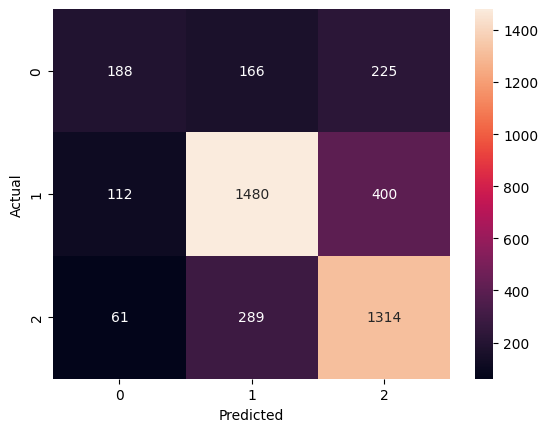

In [17]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred_glove)
print(cm)

sns.heatmap(cm, annot=True, fmt='d')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

Install Gensim

In [18]:
!pip install gensim

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 4.3 MB/s eta 0:00:00


Load Model FastText Sederhana

In [19]:
from gensim.models import FastText

sentences = df_cleaned['tokens'].tolist()

ft_model = FastText(sentences, vector_size=100, window=5, min_count=2)

Sentence Vector pakai average word vector


In [20]:
import numpy as np

def sentence_vector_ft(tokens):
    vectors = []
    for word in tokens:
        if word in ft_model.wv:
            vectors.append(ft_model.wv[word])

    if len(vectors) == 0:
        return np.zeros(100)

    return np.mean(vectors, axis=0)

X_ft = np.array(df_cleaned['tokens'].apply(sentence_vector_ft).tolist())
y = df_cleaned['label'].values


Split Training dan Test Data

In [21]:
from sklearn.model_selection import train_test_split

X_train_f, X_test_f, y_train, y_test = train_test_split(X_ft, y, test_size=0.2)

Modeling

In [22]:
from sklearn.linear_model import LogisticRegression

model_ft = LogisticRegression(max_iter=200)
model_ft.fit(X_train_f, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression(max_iter=200)

In [ ]:
svm_ft = SVC()
svm_ft.fit(X_train_f, y_train)

SVC()

Evaluation

In [23]:
y_pred_ft = model_ft.predict(X_test_f)

In [24]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report


print("=== FastText ===")
print(classification_report(y_test, y_pred_ft))

=== FastText ===
              precision    recall  f1-score   support

          -1       0.45      0.23      0.30       583
           0       0.66      0.75      0.71      1958
           1       0.66      0.67      0.67      1694

    accuracy                           0.65      4235
   macro avg       0.59      0.55      0.56      4235
weighted avg       0.63      0.65      0.63      4235



In [25]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred_ft)
print("Accuracy:", accuracy)

Accuracy: 0.6481700118063755


[[ 132  243  208]
 [ 109 1477  372]
 [  54  504 1136]]


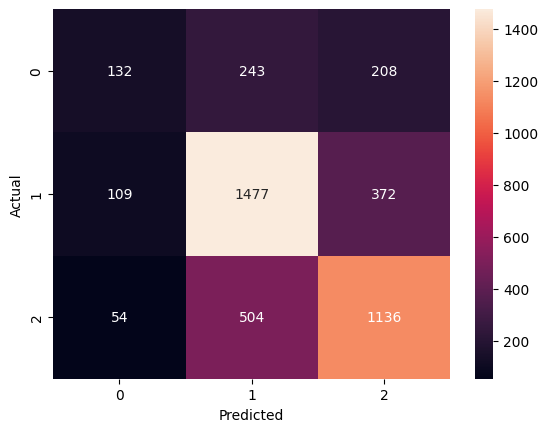

In [26]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred_ft)
print(cm)

sns.heatmap(cm, annot=True, fmt='d')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [27]:
import joblib

# simpan model
joblib.dump(model_ft, 'model_fasttext_lr.pkl')


#model_fasttext_lr.bin
#model_fasttext_lr.h5
#model_fasttext_lr.model

['model_fasttext_lr.pkl']